In [2]:
#import libraries

#image management
from photutils.aperture import EllipticalAperture
from photutils.aperture import EllipticalAnnulus
from photutils.aperture import aperture_photometry
from photutils.centroids import centroid_com
from astropy.nddata import Cutout2D
from photutils.segmentation import detect_sources
from astropy.visualization import ZScaleInterval, ImageNormalize
from photutils.background import Background2D, MedianBackground

#plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.cbook as cbook
from matplotlib_scalebar.scalebar import ScaleBar

#astro handeling
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
import astropy.units as u
import pyregion
import sep

#math
import numpy as np
from astropy.visualization import simple_norm
from astropy.stats import SigmaClip

#data frame handeling
import pandas as pd

#pdf handeling
from matplotlib.backends.backend_pdf import PdfPages

#exception handeling
import warnings
warnings.simplefilter('ignore')

#lab handeling
from IPython.display import clear_output
import time

#custom stuff
import Galaxy_info as gi
import utils

In [3]:
#galaxies
galaxy_id = ["WLM", "IC 10", "NGC 4214", "UGC 8508", "DDO 50", "DDO 53"]

#file data
file = gi.Galaxy_Info[galaxy_id[1]]

#galaxy name
galaxy = file[0]

#hi file
hi_fits = file[1]

#ha file
ha_fits = file[8]#2

#ha csv file
ha_csv = file[3]

#irac file
irac_fits = file[9]#4

#irac csv file
irac_csv = file[5]

#region file
region_file = file[6]

#distance to galxy kpc
distance = file[7]

In [4]:
#load image
#open ha fits file
hdu_ha = fits.open(ha_fits)

#read in ha header
header_ha = hdu_ha[0].header

#read in ha image as numpy array
ha_image = hdu_ha[0].data

#correct ha image for noise
masked_ha = utils.subtract_noise(ha_image)#utils.mask_stars(ha_image)

#read in ha wcs data
wcs_ha = WCS(header_ha)

#read in ha pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_ha else "CDELT2"
arcsec_per_pixel_ha = np.abs(header_ha[cdelt]) * 3600

#get ha flux units
try:
    unit_ha = (10**header_ha["RESPONSE"])
except:
    unit_ha = 1

#open hi fits file
hdu_hi = fits.open(hi_fits)

#read in hi header
header_hi = hdu_hi[0].header

#read in hi image as numpy array
hi_image = hdu_hi[0].data

#correct hi image for noise
masked_hi = hi_image.squeeze()#utils.subtract_noise(ha_image)#utils.mask_stars(ha_image)

#read in hi wcs data
wcs_hi = WCS(header_hi)

#read in hi pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_hi else "CDELT2"
arcsec_per_pixel_hi = np.abs(header_hi[cdelt]) * 3600

#open irac fits file
hdu_irac = fits.open(irac_fits)

#read in ha header
header_irac = hdu_irac[0].header

#read in ha image as numpy array
irac_image = hdu_irac[0].data

#correct ha image for noise
masked_irac = utils.subtract_noise(irac_image)#utils.mask_stars(ha_image)

#read in ha wcs data
wcs_irac = WCS(header_irac)

#read in ha pixel to arcsec conversion
cdelt = "CD2_2" if "CD2_2" in header_irac else "CDELT2"
arcsec_per_pixel_irac = np.abs(header_irac[cdelt]) * 3600

In [5]:
#load region

#region index
index = 7

#read in regions
regions = pyregion.open(region_file)

print(regions)

#read in region
region = regions[index]

#load region characteristics

#grab coords of region center - coord_list: [RA, Dec, a_arcsec, b_arcsec, PA]
ra, dec, a_arcsec, b_arcsec, pa_deg = region.coord_list

#convert region center to pixel
skycoord = SkyCoord(ra=ra*u.deg, dec=dec*u.deg)
x_hi, y_hi = skycoord.to_pixel(wcs_hi)
x_ha, y_ha = skycoord.to_pixel(wcs_ha)
x_irac, y_irac = skycoord.to_pixel(wcs_irac)

#convert to rads
theta = np.deg2rad(pa_deg)
print(ra, dec, pa_deg)

#convert hi arcsec → pixels
a_pix_hi = a_arcsec * 3600/ arcsec_per_pixel_hi 
b_pix_hi = b_arcsec * 3600/ arcsec_per_pixel_hi

#convert ha arcsec → pixels
a_pix_ha = a_arcsec * 3600/ arcsec_per_pixel_ha
b_pix_ha = b_arcsec * 3600/ arcsec_per_pixel_ha

#convert irac arcsec → pixels
a_pix_irac = a_arcsec * 3600/ arcsec_per_pixel_irac
b_pix_irac = b_arcsec * 3600/ arcsec_per_pixel_irac

[Shape : ellipse ( HMS(00:19:52.1),DMS(+59:18:05.1),Ang(11.93"),Ang(11.93"),Number(90) ), Shape : ellipse ( HMS(00:19:53.2),DMS(+59:17:30.6),Ang(12.23"),Ang(6.11"),Number(9) ), Shape : ellipse ( HMS(00:20:00.3),DMS(+59:17:51.5),Ang(36.83"),Ang(25.78"),Number(15) ), Shape : ellipse ( HMS(00:20:06.3),DMS(+59:19:33.8),Ang(19.01"),Ang(11.40"),Number(85) ), Shape : ellipse ( HMS(00:20:10.7),DMS(+59:16:59.3),Ang(29.47"),Ang(8.84"),Number(2) ), Shape : ellipse ( HMS(00:20:13.4),DMS(+59:17:44.3),Ang(26.67"),Ang(18.67"),Number(151) ), Shape : ellipse ( HMS(00:20:15.2),DMS(+59:16:50.3),Ang(19.89"),Ang(13.92"),Number(10) ), Shape : ellipse ( HMS(00:20:16.7),DMS(+59:19:36.9),Ang(33.15"),Ang(23.20"),Number(174) ), Shape : ellipse ( HMS(00:20:17.3),DMS(+59:18:39.9),Ang(7.51"),Ang(7.51"),Number(90) ), Shape : ellipse ( HMS(00:20:22.0),DMS(+59:18:26.4),Ang(34.92"),Ang(24.44"),Number(139) ), Shape : ellipse ( HMS(00:20:22.2),DMS(+59:17:29.4),Ang(10.02"),Ang(6.01"),Number(134) ), Shape : ellipse ( HMS(0

In [6]:
#generate cutout
try:
    cutout, z = utils.cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, masked_ha)
except Exception as e:
    print(e)

In [7]:
#initialize zscale
zscale = ZScaleInterval()

In [8]:
#generate ha flux data
radii_ha, flux_ha, rim_core_ha = utils.sum_core_to_rim_pix((x_ha, y_ha), a_pix_ha/b_pix_ha, theta, masked_ha, \
                                                         arcsec_per_pixel_ha, a_pix_ha)
        
                
#convert ha radii to kpc
radii_ha = utils.arcsecs_to_radius(radii_ha, distance)

#convert ha flux to erg/s/cm^2/A
flux_ha = flux_ha * unit_ha

#generate hi flux data
radii_hi, flux_hi, rim_core_hi = utils.sum_core_to_rim_pix((x_hi, y_hi), a_pix_hi/b_pix_hi, theta, masked_hi, \
                                                         arcsec_per_pixel_hi, a_pix_hi)            
#convert hi radii to kpc
radii_hi = utils.arcsecs_to_radius(radii_hi, distance)

#initialize hi rim
hi_rim = utils.arcsecs_to_radius(a_pix_hi * arcsec_per_pixel_hi, distance)

#calculate irac flux
radii_irac, flux_irac, rim_core_irac = utils.sum_core_to_rim_pix((x_irac, y_irac), a_pix_irac/b_pix_irac, theta, masked_irac, \
                                         arcsec_per_pixel_irac, a_pix_irac)

#convert radii to kpc
radii_irac = utils.arcsecs_to_radius(radii_irac, distance)

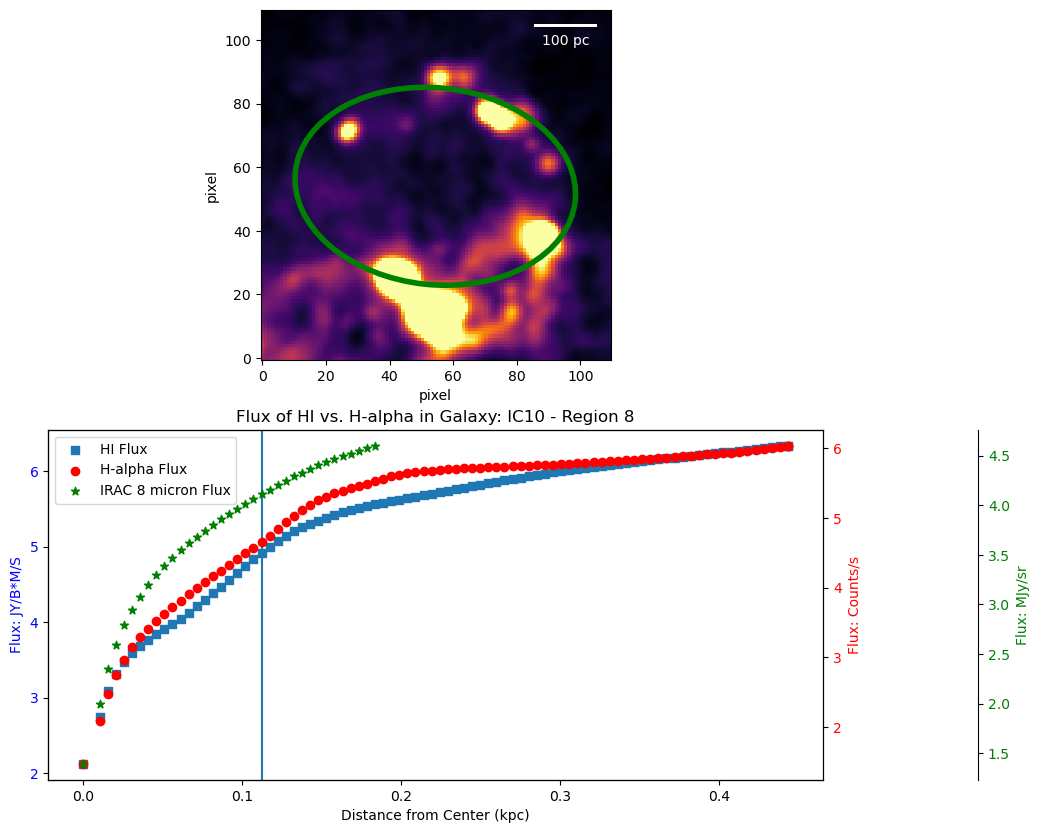

In [11]:
#intialize frames
stop = 4
frames = len(radii_hi)
ha_hi_ratio = len(radii_ha) / frames
irac_hi_ratio = len(radii_irac) / frames

#iterate frames
for frame in range(0, frames + 1):

    #initialize figure
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))
    # fig, axs = plt.subplots(1, 2, figsize=(20, 5))

    #generate ellipse scale
    ellipse_scale_ha = (frame / frames) * stop# * ha_hi_ratio

    #print(ellipse_scale_ha)

    #generate cutout and ellipse
    cutout, ellipse = utils.cut_mark_image((x_ha, y_ha), a_pix_ha, b_pix_ha, theta, masked_ha, ellipse_scale_ha)

    #plot cutout
    utils.plot_fits(cutout, arcsec_per_pixel_ha, distance, axs[0], ellipse)

    #plot core to rim
    ax1 = axs[1]
    utils.plot_core_rim(np.append(radii_hi[:frame], radii_hi[-1]), np.append(flux_hi[:frame], flux_hi[-1]), \
                        \
                        np.append(radii_ha[:int(frame * ha_hi_ratio)], radii_ha[-1]), np.append(flux_ha[:int(frame * ha_hi_ratio)], flux_ha[-1]), \
                        \
                        np.append(radii_irac[:int(frame * irac_hi_ratio)], radii_irac[-1]), np.append(flux_irac[:int(frame * irac_hi_ratio)], flux_irac[-30]), \
                        \
                        ax1, galaxy, index, hi_rim, unit_ha)

        
    #show plot
    plt.show()

    #clear jupyter output
    clear_output(wait=True)
    
    #delay
    if frame == 0:
        time.sleep(5)
    else:
        time.sleep(.07)

